### Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyreadstat
 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.validation import check_is_fitted
 
sns.set_style("whitegrid")

# Loading the Datasets

## HMDA

In [2]:
HMDA_PATH = r"C:\Users\Admin\Documents\Python Projects\state_LA-CA.csv"  # adjust to your actual HMDA file path
NIDS_DIR = r"C:\Users\Admin\Documents\Python Projects\nids-w5-2017-stata11"

In [3]:
hmda_raw = pd.read_csv(HMDA_PATH, low_memory=False)
print("HMDA raw shape:", hmda_raw.shape)


HMDA raw shape: (1097982, 99)


## German Credit Data

In [4]:
german_columns = [
    "checking_account_status", "duration_months", "credit_history", "purpose",
    "credit_amount", "savings_account", "employment_since", "installment_rate_pct",
    "personal_status_sex", "other_debtors_guarantors", "present_residence_since",
    "property", "age", "other_installment_plans", "housing",
    "existing_credits_count", "job", "num_dependents", "telephone",
    "foreign_worker", "target"
]
german_final = pd.read_csv(r"C:\Users\Admin\Documents\Python Projects\statlog+german+credit+data\german.data", sep=" ", header=None, names=german_columns)
german_final["target"] = german_final["target"].map({1: 1, 2: 0})  # 1 = good credit, 0 = bad credit
print("German Credit shape:", german_final.shape)



German Credit shape: (1000, 21)


## NIDS

In [5]:
adult_df = pd.read_stata(NIDS_DIR + r"\adult_w5_anon_v1.0.0-stata11.dta", convert_categoricals=True)
age_df = pd.read_stata(NIDS_DIR + r"\indderived_w5_anon_v1.0.0-stata11.dta", convert_categoricals=True)[
    ["pid", "w5_best_age_yrs"]
]
print("NIDS adult file shape:", adult_df.shape)

NIDS adult file shape: (30110, 1144)


# Data Cleaning

## HMDA

In [6]:
hmda = hmda_raw[hmda_raw["action_taken"].isin([1, 2, 3])].copy()
hmda["approved"] = hmda["action_taken"].map({1: 1, 2: 1, 3: 0})

In [7]:
valid_race_codes = [1, 2, 3, 4, 5, 6]
hmda = hmda[hmda["applicant_race-1"].isin(valid_race_codes)]

In [8]:
def clean_dti(val):
    val = str(val).strip()
    if val in ("Exempt", "NaN", "nan", "NA", "None"):
        return None
    band_midpoints = {"<20%": 15, "20%-<30%": 25, "30%-<36%": 33, "50%-60%": 55, ">60%": 65}
    if val in band_midpoints:
        return band_midpoints[val]
    try:
        return float(val)
    except ValueError:
        return None

In [9]:
hmda["debt_to_income_ratio"] = hmda["debt_to_income_ratio"].apply(clean_dti)


In [10]:
hmda["dti_missing"] = hmda["debt_to_income_ratio"].isna().astype(int)

In [11]:
hmda["property_value"] = pd.to_numeric(hmda["property_value"], errors="coerce")
hmda["loan_to_value_ratio"] = pd.to_numeric(hmda["loan_to_value_ratio"], errors="coerce")

In [12]:
hmda_cols_needed = [
    "approved", "applicant_race-1", "applicant_ethnicity-1", "applicant_sex",
    "income", "loan_amount", "loan_to_value_ratio", "debt_to_income_ratio", "dti_missing",
    "county_code", "loan_purpose", "property_value"
]
hmda_final = hmda[hmda_cols_needed].copy()
print("HMDA after row/column cleaning:", hmda_final.shape)

HMDA after row/column cleaning: (686685, 12)


In [13]:
hmda_final = pd.get_dummies(hmda_final, columns=["loan_purpose"], prefix="purpose", drop_first=True)
 

In [14]:
top_counties = hmda_final["county_code"].value_counts().nlargest(20).index
hmda_final["county_grouped"] = hmda_final["county_code"].where(
    hmda_final["county_code"].isin(top_counties), "Other"
)
hmda_final = hmda_final.drop(columns=["county_code"])  # <-- critical: must drop raw column explicitly
hmda_final = pd.get_dummies(hmda_final, columns=["county_grouped"], prefix="county", drop_first=True)
assert "county_code" not in hmda_final.columns


## German Credit Data

In [15]:
# %% [GER-2] Extract sex and foreign-worker status as clean, standalone sensitive attributes
sex_map = {"A91": "male", "A92": "female", "A93": "male", "A94": "male", "A95": "female"}
german_final["sex"] = german_final["personal_status_sex"].map(sex_map)
 
foreign_worker_map = {"A201": "yes", "A202": "no"}
german_final["foreign_worker_status"] = german_final["foreign_worker"].map(foreign_worker_map)
 


## NIDS

In [16]:
# %% [NIDS-2] Pull only the columns needed, in one place
nids_cols_needed = [
    "pid", "w5_a_popgrp", "w5_a_gen",
    "w5_a_edschgrd", "w5_a_fwbrelinc", "w5_a_brnprov",
    "w5_a_dtbnd", "w5_a_dtbnk", "w5_a_dtcre", "w5_a_dtstubnk", "w5_a_dtstuo"
]
nids_final = adult_df[nids_cols_needed].copy()

In [17]:
# [NIDS-3] Rebuild holds_formal_debt target from the five loan-type flags
def clean_yesno(series):
    return series.map({"Yes": 1, "No": 0}).astype("float")
 
formal_debt_vars = ["w5_a_dtbnd", "w5_a_dtbnk", "w5_a_dtcre", "w5_a_dtstubnk", "w5_a_dtstuo"]
for col in formal_debt_vars:
    nids_final[col + "_clean"] = clean_yesno(nids_final[col])
 
clean_cols = [c + "_clean" for c in formal_debt_vars]
 
def combine_debt(row):
    if (row[clean_cols] == 1).any():
        return 1
    elif row[clean_cols].isnull().all():
        return np.nan
    elif (row[clean_cols] == 0).sum() + row[clean_cols].isnull().sum() == len(clean_cols):
        return 0
    else:
        return np.nan
 
nids_final["holds_formal_debt"] = nids_final.apply(combine_debt, axis=1)

In [18]:
# %% [NIDS-4] Merge in age, force to numeric (catches "Don't Know" string values -> NaN)
nids_final = nids_final.merge(age_df, on="pid", how="left")
nids_final["w5_best_age_yrs"] = pd.to_numeric(nids_final["w5_best_age_yrs"], errors="coerce")


In [38]:
#[NIDS-6] Drop rows missing genuine predictors; treat missing PROXY (province, 60% missing) as "Unknown" instead
nids_model_df = nids_final.dropna(subset=["w5_a_edschgrd", "w5_a_fwbrelinc", "w5_best_age_yrs", "holds_formal_debt"]).copy()
 
nids_model_df["w5_a_brnprov"] = nids_model_df["w5_a_brnprov"].astype(str)
nids_model_df["w5_a_brnprov"] = nids_model_df["w5_a_brnprov"].replace(
    {"nan": "Unknown", "Missing": "Unknown", "Don't know": "Unknown", "Refused": "Unknown"}
)

# Data Visualization

## HMDA

In [20]:

sns.set_style("whitegrid")

race_labels = {
    1: "American Indian/\nAlaska Native", 2: "Asian", 3: "Black or African\nAmerican",
    4: "Native Hawaiian/\nPacific Islander", 5: "White", 6: "Not Provided"
}
hmda_race_display = hmda_final["applicant_race-1"].map(race_labels)  # temporary, not stored in hmda_final

### Approval by Balance

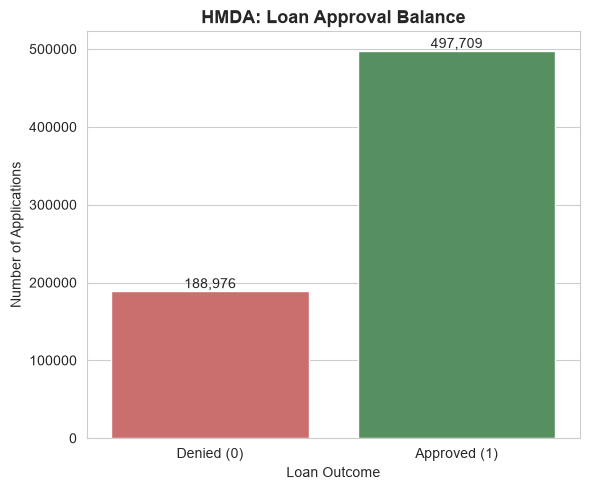

In [21]:

plt.figure(figsize=(6, 5))
ax = sns.countplot(x="approved", data=hmda_final, order=[0, 1], hue="approved",
                    palette=["#d95f5f", "#4c9a5b"], legend=False)
ax.set_xticks([0, 1]); ax.set_xticklabels(["Denied (0)", "Approved (1)"])
ax.set_xlabel("Loan Outcome"); ax.set_ylabel("Number of Applications")
ax.set_title("HMDA: Loan Approval Balance", fontsize=13, fontweight="bold")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=10)
plt.tight_layout(); plt.show()

### Approval by Race

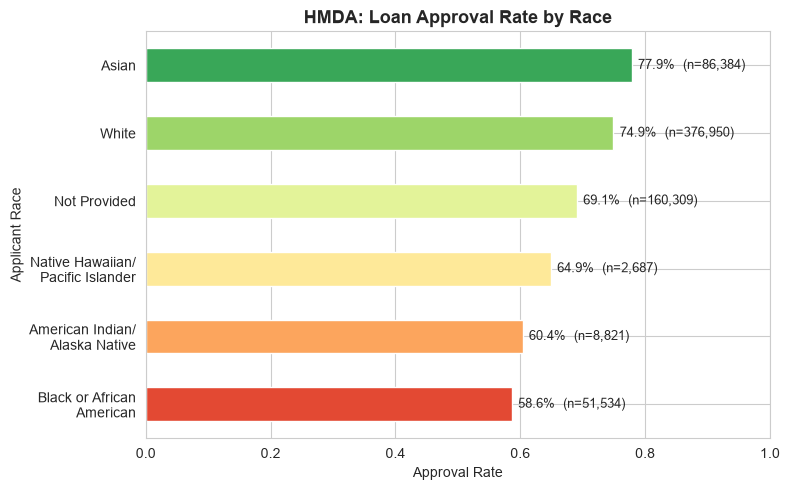

In [22]:
# 2. Approval rate by race
plt.figure(figsize=(8, 5))
race_approval = pd.DataFrame({"race": hmda_race_display, "approved": hmda_final["approved"]}) \
    .groupby("race", observed=True)["approved"].agg(["mean", "count"]).sort_values("mean")
colors = sns.color_palette("RdYlGn", len(race_approval))
ax = race_approval["mean"].plot(kind="barh", color=colors)
ax.set_xlabel("Approval Rate"); ax.set_ylabel("Applicant Race")
ax.set_title("HMDA: Loan Approval Rate by Race", fontsize=13, fontweight="bold")
ax.set_xlim(0, 1)
for i, (rate, n) in enumerate(zip(race_approval["mean"], race_approval["count"])):
    ax.text(rate + 0.01, i, f"{rate:.1%}  (n={n:,})", va="center", fontsize=9)
plt.tight_layout(); plt.show()

### Income by Outcome

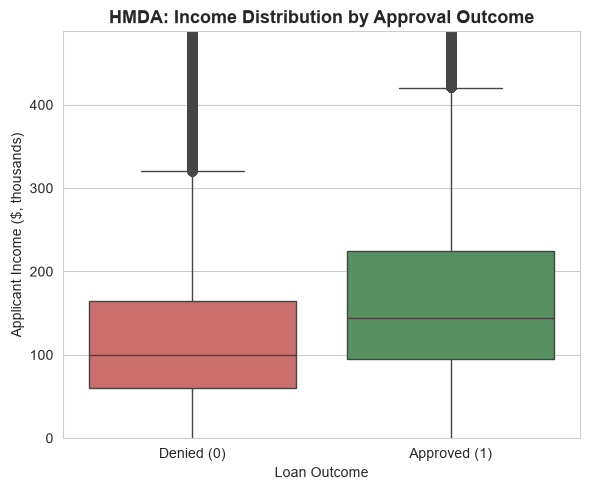

In [23]:
plt.figure(figsize=(6, 5))
ax = sns.boxplot(x="approved", y="income", data=hmda_final, order=[0, 1], hue="approved",
                  palette=["#d95f5f", "#4c9a5b"], legend=False)
ax.set_xticks([0, 1]); ax.set_xticklabels(["Denied (0)", "Approved (1)"])
ax.set_xlabel("Loan Outcome"); ax.set_ylabel("Applicant Income ($, thousands)")
ax.set_title("HMDA: Income Distribution by Approval Outcome", fontsize=13, fontweight="bold")
ax.set_ylim(0, hmda_final["income"].quantile(0.95))
plt.tight_layout(); plt.show()

## German Credit Data

### Target Balance

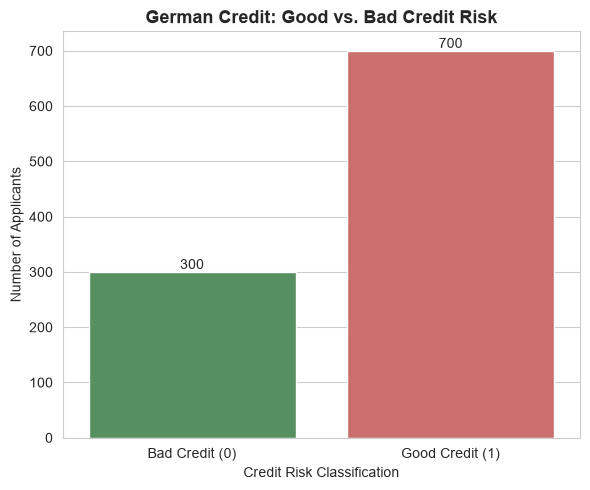

In [24]:
target_labels = {0: "Bad Credit (0)", 1: "Good Credit (1)"}
german_target_display = german_final["target"].map(target_labels)  # temporary, not stored

# 1. Target balance
plt.figure(figsize=(6, 5))
ax = sns.countplot(x=german_target_display, order=["Bad Credit (0)", "Good Credit (1)"],
                    hue=german_target_display, palette=["#d95f5f", "#4c9a5b"], legend=False)
ax.set_xlabel("Credit Risk Classification"); ax.set_ylabel("Number of Applicants")
ax.set_title("German Credit: Good vs. Bad Credit Risk", fontsize=13, fontweight="bold")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=10)
plt.tight_layout(); plt.show()

### Good Credit Rate by Sex

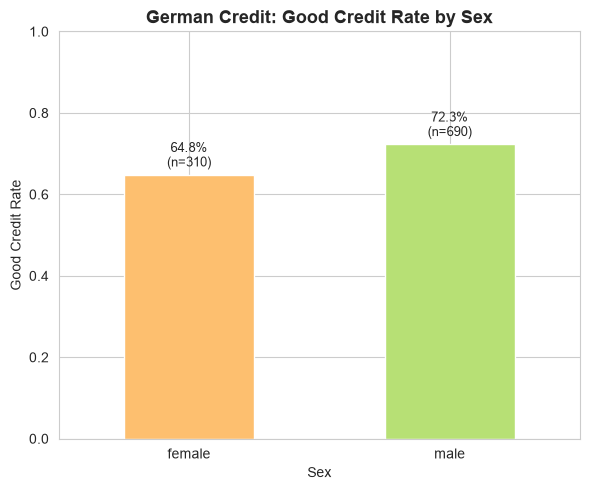

In [25]:
# 2. Good credit rate by sex
plt.figure(figsize=(6, 5))
sex_rate = german_final.groupby("sex")["target"].agg(["mean", "count"])
ax = sex_rate["mean"].plot(kind="bar", color=sns.color_palette("RdYlGn", len(sex_rate)))
ax.set_xlabel("Sex"); ax.set_ylabel("Good Credit Rate")
ax.set_title("German Credit: Good Credit Rate by Sex", fontsize=13, fontweight="bold")
ax.set_ylim(0, 1); plt.xticks(rotation=0)
for i, (rate, n) in enumerate(zip(sex_rate["mean"], sex_rate["count"])):
    ax.text(i, rate + 0.02, f"{rate:.1%}\n(n={n})", ha="center", fontsize=9)
plt.tight_layout(); plt.show()


### Good Credit Rate by Foreign Worker Status

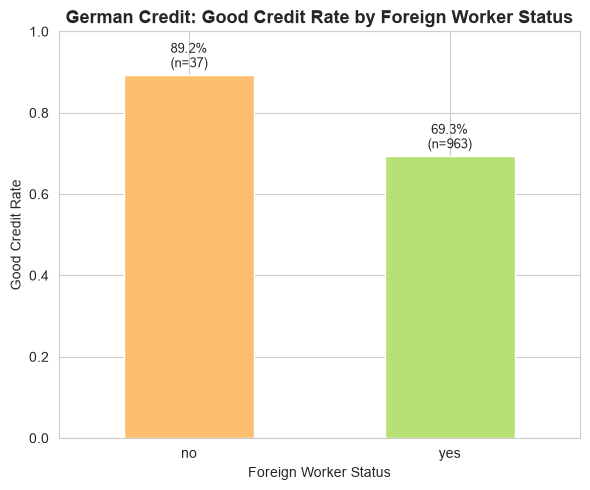

In [26]:
plt.figure(figsize=(6, 5))
fw_rate = german_final.groupby("foreign_worker_status")["target"].agg(["mean", "count"])
ax = fw_rate["mean"].plot(kind="bar", color=sns.color_palette("RdYlGn", len(fw_rate)))
ax.set_xlabel("Foreign Worker Status"); ax.set_ylabel("Good Credit Rate")
ax.set_title("German Credit: Good Credit Rate by Foreign Worker Status", fontsize=13, fontweight="bold")
ax.set_ylim(0, 1); plt.xticks(rotation=0)
for i, (rate, n) in enumerate(zip(fw_rate["mean"], fw_rate["count"])):
    ax.text(i, rate + 0.02, f"{rate:.1%}\n(n={n})", ha="center", fontsize=9)
plt.tight_layout(); plt.show()

In [27]:
print("Rows before dropping missing target:", len(nids_final))
nids_final = nids_final.dropna(subset=["holds_formal_debt"]).copy()
print("Rows after dropping missing target:", len(nids_final))

Rows before dropping missing target: 30110
Rows after dropping missing target: 23872


## NIDS

### Target Balance

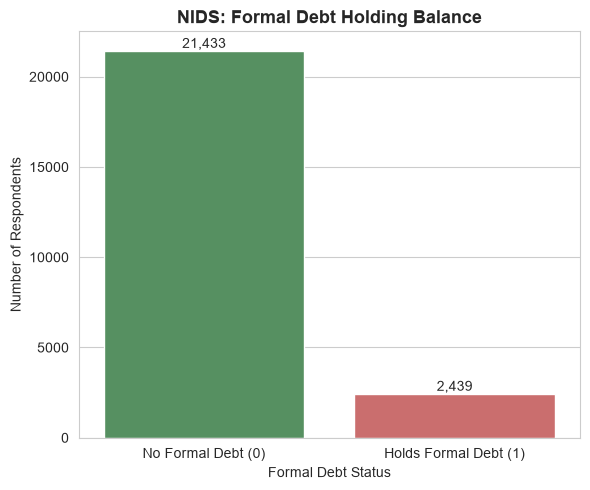

In [28]:
debt_labels = {0: "No Formal Debt (0)", 1: "Holds Formal Debt (1)"}
nids_debt_display = nids_final["holds_formal_debt"].astype(int).map(debt_labels)  # temporary, not stored

# 1. Target balance
plt.figure(figsize=(6, 5))
ax = sns.countplot(x=nids_debt_display, order=["No Formal Debt (0)", "Holds Formal Debt (1)"],
                    hue=nids_debt_display, palette=["#d95f5f", "#4c9a5b"], legend=False)
ax.set_xlabel("Formal Debt Status"); ax.set_ylabel("Number of Respondents")
ax.set_title("NIDS: Formal Debt Holding Balance", fontsize=13, fontweight="bold")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=10)
plt.tight_layout(); plt.show()

### Formal Debt Holding by Population Group

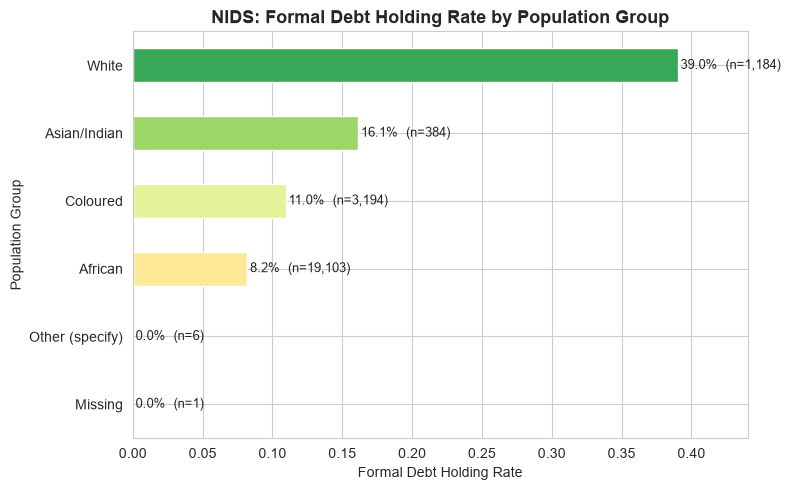

In [29]:
nids_final["w5_a_popgrp"] = nids_final["w5_a_popgrp"].cat.remove_unused_categories()

plt.figure(figsize=(8, 5))
popgrp_rate = nids_final.groupby("w5_a_popgrp", observed=True)["holds_formal_debt"].agg(["mean", "count"]).sort_values("mean")
colors = sns.color_palette("RdYlGn", len(popgrp_rate))
ax = popgrp_rate["mean"].plot(kind="barh", color=colors)
ax.set_xlabel("Formal Debt Holding Rate"); ax.set_ylabel("Population Group")
ax.set_title("NIDS: Formal Debt Holding Rate by Population Group", fontsize=13, fontweight="bold")
ax.set_xlim(0, max(popgrp_rate["mean"]) + 0.05)
for i, (rate, n) in enumerate(zip(popgrp_rate["mean"], popgrp_rate["count"])):
    ax.text(rate + 0.002, i, f"{rate:.1%}  (n={n:,})", va="center", fontsize=9)
plt.tight_layout(); plt.show()

# Feature Engineering

## HMDA

In [30]:
# %% [HMDA-9] Scale numeric predictors (median-impute DTI's nulls here, but dti_missing flag preserves the signal)
hmda_numeric_cols = ["income", "loan_amount", "loan_to_value_ratio", "debt_to_income_ratio", "property_value"]
hmda_scaler = StandardScaler()
hmda_final[[c + "_scaled" for c in hmda_numeric_cols]] = hmda_scaler.fit_transform(
    hmda_final[hmda_numeric_cols].fillna(hmda_final[hmda_numeric_cols].median())
)
 


In [31]:
# %% [HMDA-10] Assemble feature groups
hmda_predictors = ["income_scaled", "loan_amount_scaled", "loan_to_value_ratio_scaled",
                    "debt_to_income_ratio_scaled", "property_value_scaled", "dti_missing"] + \
                   [c for c in hmda_final.columns if c.startswith("purpose_")]
hmda_proxy = [c for c in hmda_final.columns if c.startswith("county_")]
hmda_sensitive = ["applicant_race-1", "applicant_sex", "applicant_ethnicity-1"]
 
X_hmda = hmda_final[hmda_predictors + hmda_proxy]
X_hmda_no_proxy = hmda_final[hmda_predictors]
y_hmda = hmda_final["approved"]
sens_hmda = hmda_final[hmda_sensitive]

## German Credit Data

In [32]:
 #%% [GER-3] One-hot encode categorical predictors (personal_status_sex deliberately EXCLUDED — it's the
# source of the sensitive "sex" attribute above and must not leak into the model inputs)
german_categorical_cols = [
    "checking_account_status", "credit_history", "purpose", "savings_account",
    "employment_since", "other_debtors_guarantors", "property",
    "other_installment_plans", "housing", "job", "telephone"
]
german_encoded = pd.get_dummies(german_final, columns=german_categorical_cols, drop_first=True)

In [33]:
# %% [GER-4] Scale numeric predictors — dataset-specific variable name to avoid collision with HMDA/NIDS
german_numeric_cols = ["duration_months", "credit_amount", "installment_rate_pct",
                        "present_residence_since", "age", "existing_credits_count", "num_dependents"]
german_scaler = StandardScaler()
german_encoded[[c + "_scaled" for c in german_numeric_cols]] = german_scaler.fit_transform(
    german_encoded[german_numeric_cols]
)

In [34]:
# %% [GER-5] Assemble feature groups
german_predictors = [c + "_scaled" for c in german_numeric_cols] + \
    [c for c in german_encoded.columns if any(c.startswith(p) for p in german_categorical_cols)]
german_proxy_cols = ["age_scaled"]
german_predictors_no_proxy = [c for c in german_predictors if c != "age_scaled"]
german_sensitive = ["sex", "foreign_worker_status"]
 
X_german = german_encoded[german_predictors]
X_german_no_proxy = german_encoded[german_predictors_no_proxy]
y_german = german_encoded["target"]
sens_german = german_encoded[german_sensitive]
 
print("German Credit final shapes:", X_german.shape, X_german_no_proxy.shape, y_german.shape, sens_german.shape)
assert X_german.select_dtypes(include="object").shape[1] == 0, "German Credit still has non-numeric predictors"


German Credit final shapes: (1000, 44) (1000, 43) (1000,) (1000, 2)


## NIDS

In [40]:
# %% [NIDS-7] One-hot encode categorical predictors + proxy
nids_model_df = pd.get_dummies(
    nids_model_df,
    columns=["w5_a_edschgrd", "w5_a_fwbrelinc", "w5_a_brnprov"],
    prefix=["educ", "incomecat", "province"],
    drop_first=True
)


In [41]:
# %% [NIDS-8] Scale age — dataset-specific variable name
nids_scaler = StandardScaler()
nids_model_df["age_scaled"] = nids_scaler.fit_transform(nids_model_df[["w5_best_age_yrs"]])
 

In [42]:
# %% [NIDS-9] Assemble feature groups; force target to clean int (was showing as object/pd.NA dtype)
nids_predictors = ["age_scaled"] + \
    [c for c in nids_model_df.columns if c.startswith("educ_") or c.startswith("incomecat_")]
nids_proxy_cols = [c for c in nids_model_df.columns if c.startswith("province_")]
nids_sensitive_cols = ["w5_a_popgrp", "w5_a_gen"]
 
X_nids = nids_model_df[nids_predictors + nids_proxy_cols]
X_nids_no_proxy = nids_model_df[nids_predictors]
y_nids = nids_model_df["holds_formal_debt"].astype(int)
sens_nids = nids_model_df[nids_sensitive_cols]
 
print("NIDS final shapes:", X_nids.shape, X_nids_no_proxy.shape, y_nids.shape, sens_nids.shape)
assert X_nids.isnull().sum().sum() == 0, "NIDS still has nulls — check before proceeding"


NIDS final shapes: (23871, 41) (23871, 31) (23871,) (23871, 2)


# Train, Test and Split All Datasets

## Split 

In [43]:
# %% [SPLIT] HMDA
X_hmda_train, X_hmda_test, X_hmda_np_train, X_hmda_np_test, y_hmda_train, y_hmda_test, sens_hmda_train, sens_hmda_test = train_test_split(
    X_hmda, X_hmda_no_proxy, y_hmda, sens_hmda, test_size=0.2, stratify=y_hmda, random_state=42
)
 
# %% [SPLIT] German Credit
X_ger_train, X_ger_test, X_ger_np_train, X_ger_np_test, y_ger_train, y_ger_test, sens_ger_train, sens_ger_test = train_test_split(
    X_german, X_german_no_proxy, y_german, sens_german, test_size=0.2, stratify=y_german, random_state=42
)
 
# %% [SPLIT] NIDS
X_nids_train, X_nids_test, X_nids_np_train, X_nids_np_test, y_nids_train, y_nids_test, sens_nids_train, sens_nids_test = train_test_split(
    X_nids, X_nids_no_proxy, y_nids, sens_nids, test_size=0.2, stratify=y_nids, random_state=42
)


In [44]:
print("Split shapes:")
print("HMDA:", X_hmda_train.shape, X_hmda_test.shape)
print("German:", X_ger_train.shape, X_ger_test.shape)
print("NIDS:", X_nids_train.shape, X_nids_test.shape)
 


Split shapes:
HMDA: (549348, 31) (137337, 31)
German: (800, 44) (200, 44)
NIDS: (19096, 41) (4775, 41)


## Train

### Models with Proxy Versions

In [45]:

log_reg_hmda = LogisticRegression(max_iter=1000, class_weight="balanced").fit(X_hmda_train, y_hmda_train)
rf_hmda = RandomForestClassifier(n_estimators=300, max_depth=10, class_weight="balanced", random_state=42).fit(X_hmda_train, y_hmda_train)
 
log_reg_ger = LogisticRegression(max_iter=1000, class_weight="balanced").fit(X_ger_train, y_ger_train)
rf_ger = RandomForestClassifier(n_estimators=300, max_depth=10, class_weight="balanced", random_state=42).fit(X_ger_train, y_ger_train)
 
log_reg_nids = LogisticRegression(max_iter=1000, class_weight="balanced").fit(X_nids_train, y_nids_train)
rf_nids = RandomForestClassifier(n_estimators=300, max_depth=10, class_weight="balanced", random_state=42).fit(X_nids_train, y_nids_train)
 

### Models without Proxy Versions

In [46]:
log_reg_hmda_np = LogisticRegression(max_iter=1000, class_weight="balanced").fit(X_hmda_np_train, y_hmda_train)
rf_hmda_np = RandomForestClassifier(n_estimators=300, max_depth=10, class_weight="balanced", random_state=42).fit(X_hmda_np_train, y_hmda_train)
 
log_reg_ger_np = LogisticRegression(max_iter=1000, class_weight="balanced").fit(X_ger_np_train, y_ger_train)
rf_ger_np = RandomForestClassifier(n_estimators=300, max_depth=10, class_weight="balanced", random_state=42).fit(X_ger_np_train, y_ger_train)
 
log_reg_nids_np = LogisticRegression(max_iter=1000, class_weight="balanced").fit(X_nids_np_train, y_nids_train)
rf_nids_np = RandomForestClassifier(n_estimators=300, max_depth=10, class_weight="balanced", random_state=42).fit(X_nids_np_train, y_nids_train)
 

# Evaluating Accuracy and Fairness

In [47]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from fairlearn.metrics import demographic_parity_difference, demographic_parity_ratio, equalized_odds_difference


In [48]:
def evaluate_model(model, X_test, y_test, sens_test, sens_col, model_name):
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]

    results = {
        "model": model_name,
        "sensitive_attr": sens_col,
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds, zero_division=0),
        "f1": f1_score(y_test, preds, zero_division=0),
        "roc_auc": roc_auc_score(y_test, probs),
        "dp_diff": demographic_parity_difference(y_test, preds, sensitive_features=sens_test[sens_col]),
        "di_ratio": demographic_parity_ratio(y_test, preds, sensitive_features=sens_test[sens_col]),
        "eo_diff": equalized_odds_difference(y_test, preds, sensitive_features=sens_test[sens_col]),
    }
    return results
    

## PASS 1 — race / population-group (HMDA's primary attribute, per proposal)

In [49]:
results_list = []

# HMDA
results_list.append(evaluate_model(log_reg_hmda, X_hmda_test, y_hmda_test, sens_hmda_test, "applicant_race-1", "HMDA_LogReg_withproxy"))
results_list.append(evaluate_model(rf_hmda, X_hmda_test, y_hmda_test, sens_hmda_test, "applicant_race-1", "HMDA_RF_withproxy"))
results_list.append(evaluate_model(log_reg_hmda_np, X_hmda_np_test, y_hmda_test, sens_hmda_test, "applicant_race-1", "HMDA_LogReg_noproxy"))
results_list.append(evaluate_model(rf_hmda_np, X_hmda_np_test, y_hmda_test, sens_hmda_test, "applicant_race-1", "HMDA_RF_noproxy"))

# German Credit
results_list.append(evaluate_model(log_reg_ger, X_ger_test, y_ger_test, sens_ger_test, "sex", "German_LogReg_withproxy"))
results_list.append(evaluate_model(rf_ger, X_ger_test, y_ger_test, sens_ger_test, "sex", "German_RF_withproxy"))
results_list.append(evaluate_model(log_reg_ger_np, X_ger_np_test, y_ger_test, sens_ger_test, "sex", "German_LogReg_noproxy"))
results_list.append(evaluate_model(rf_ger_np, X_ger_np_test, y_ger_test, sens_ger_test, "sex", "German_RF_noproxy"))

# NIDS
results_list.append(evaluate_model(log_reg_nids, X_nids_test, y_nids_test, sens_nids_test, "w5_a_popgrp", "NIDS_LogReg_withproxy"))
results_list.append(evaluate_model(rf_nids, X_nids_test, y_nids_test, sens_nids_test, "w5_a_popgrp", "NIDS_RF_withproxy"))
results_list.append(evaluate_model(log_reg_nids_np, X_nids_np_test, y_nids_test, sens_nids_test, "w5_a_popgrp", "NIDS_LogReg_noproxy"))
results_list.append(evaluate_model(rf_nids_np, X_nids_np_test, y_nids_test, sens_nids_test, "w5_a_popgrp", "NIDS_RF_noproxy"))

results_df = pd.DataFrame(results_list)
print("=== Results: race / population-group ===")
print(results_df)


=== Results: race / population-group ===
                      model    sensitive_attr  accuracy  precision    recall  \
0     HMDA_LogReg_withproxy  applicant_race-1  0.687368   0.851922  0.688302   
1         HMDA_RF_withproxy  applicant_race-1  0.786314   0.879971  0.816560   
2       HMDA_LogReg_noproxy  applicant_race-1  0.688795   0.847396  0.695968   
3           HMDA_RF_noproxy  applicant_race-1  0.802231   0.879749  0.842268   
4   German_LogReg_withproxy               sex  0.670000   0.836364  0.657143   
5       German_RF_withproxy               sex  0.695000   0.837607  0.700000   
6     German_LogReg_noproxy               sex  0.665000   0.828829  0.657143   
7         German_RF_noproxy               sex  0.710000   0.859649  0.700000   
8     NIDS_LogReg_withproxy       w5_a_popgrp  0.723351   0.228664  0.719262   
9         NIDS_RF_withproxy       w5_a_popgrp  0.780524   0.275641  0.704918   
10      NIDS_LogReg_noproxy       w5_a_popgrp  0.721885   0.227979  0.721311   

## PASS 2 — sex / gender (second sensitive attribute per dataset)

In [50]:
results_list_2 = []

# HMDA
results_list_2.append(evaluate_model(log_reg_hmda, X_hmda_test, y_hmda_test, sens_hmda_test, "applicant_sex", "HMDA_LogReg_withproxy"))
results_list_2.append(evaluate_model(rf_hmda, X_hmda_test, y_hmda_test, sens_hmda_test, "applicant_sex", "HMDA_RF_withproxy"))
results_list_2.append(evaluate_model(log_reg_hmda_np, X_hmda_np_test, y_hmda_test, sens_hmda_test, "applicant_sex", "HMDA_LogReg_noproxy"))
results_list_2.append(evaluate_model(rf_hmda_np, X_hmda_np_test, y_hmda_test, sens_hmda_test, "applicant_sex", "HMDA_RF_noproxy"))

# German Credit
results_list_2.append(evaluate_model(log_reg_ger, X_ger_test, y_ger_test, sens_ger_test, "foreign_worker_status", "German_LogReg_withproxy"))
results_list_2.append(evaluate_model(rf_ger, X_ger_test, y_ger_test, sens_ger_test, "foreign_worker_status", "German_RF_withproxy"))
results_list_2.append(evaluate_model(log_reg_ger_np, X_ger_np_test, y_ger_test, sens_ger_test, "foreign_worker_status", "German_LogReg_noproxy"))
results_list_2.append(evaluate_model(rf_ger_np, X_ger_np_test, y_ger_test, sens_ger_test, "foreign_worker_status", "German_RF_noproxy"))

# NIDS
results_list_2.append(evaluate_model(log_reg_nids, X_nids_test, y_nids_test, sens_nids_test, "w5_a_gen", "NIDS_LogReg_withproxy"))
results_list_2.append(evaluate_model(rf_nids, X_nids_test, y_nids_test, sens_nids_test, "w5_a_gen", "NIDS_RF_withproxy"))
results_list_2.append(evaluate_model(log_reg_nids_np, X_nids_np_test, y_nids_test, sens_nids_test, "w5_a_gen", "NIDS_LogReg_noproxy"))
results_list_2.append(evaluate_model(rf_nids_np, X_nids_np_test, y_nids_test, sens_nids_test, "w5_a_gen", "NIDS_RF_noproxy"))

results_df_2 = pd.DataFrame(results_list_2)
print("\n=== Results: sex / gender ===")
print(results_df_2)


=== Results: sex / gender ===
                      model         sensitive_attr  accuracy  precision  \
0     HMDA_LogReg_withproxy          applicant_sex  0.687368   0.851922   
1         HMDA_RF_withproxy          applicant_sex  0.786314   0.879971   
2       HMDA_LogReg_noproxy          applicant_sex  0.688795   0.847396   
3           HMDA_RF_noproxy          applicant_sex  0.802231   0.879749   
4   German_LogReg_withproxy  foreign_worker_status  0.670000   0.836364   
5       German_RF_withproxy  foreign_worker_status  0.695000   0.837607   
6     German_LogReg_noproxy  foreign_worker_status  0.665000   0.828829   
7         German_RF_noproxy  foreign_worker_status  0.710000   0.859649   
8     NIDS_LogReg_withproxy               w5_a_gen  0.723351   0.228664   
9         NIDS_RF_withproxy               w5_a_gen  0.780524   0.275641   
10      NIDS_LogReg_noproxy               w5_a_gen  0.721885   0.227979   
11          NIDS_RF_noproxy               w5_a_gen  0.762304   0.2630

## Combined table with both sensitive attributes stacked

In [51]:
combined_results = pd.concat([results_df, results_df_2], ignore_index=True)
print("\n=== Combined results (both attributes) ===")
print(combined_results)


combined_results.to_csv("fairness_evaluation_results.csv", index=False)
print("\nSaved to fairness_evaluation_results.csv")


=== Combined results (both attributes) ===
                      model         sensitive_attr  accuracy  precision  \
0     HMDA_LogReg_withproxy       applicant_race-1  0.687368   0.851922   
1         HMDA_RF_withproxy       applicant_race-1  0.786314   0.879971   
2       HMDA_LogReg_noproxy       applicant_race-1  0.688795   0.847396   
3           HMDA_RF_noproxy       applicant_race-1  0.802231   0.879749   
4   German_LogReg_withproxy                    sex  0.670000   0.836364   
5       German_RF_withproxy                    sex  0.695000   0.837607   
6     German_LogReg_noproxy                    sex  0.665000   0.828829   
7         German_RF_noproxy                    sex  0.710000   0.859649   
8     NIDS_LogReg_withproxy            w5_a_popgrp  0.723351   0.228664   
9         NIDS_RF_withproxy            w5_a_popgrp  0.780524   0.275641   
10      NIDS_LogReg_noproxy            w5_a_popgrp  0.721885   0.227979   
11          NIDS_RF_noproxy            w5_a_popgrp  0.76

# Evaluation using SHAP

In [52]:
import shap

explainer_nids = shap.TreeExplainer(rf_nids)
shap_values_nids = explainer_nids.shap_values(X_nids_test)

print(type(shap_values_nids))
if isinstance(shap_values_nids, list):
    print(len(shap_values_nids), shap_values_nids[0].shape)
else:
    print(shap_values_nids.shape)

<class 'numpy.ndarray'>
(4775, 41, 2)


## SHAP on HMDA — testing whether county actually matters

(5000, 31, 2)


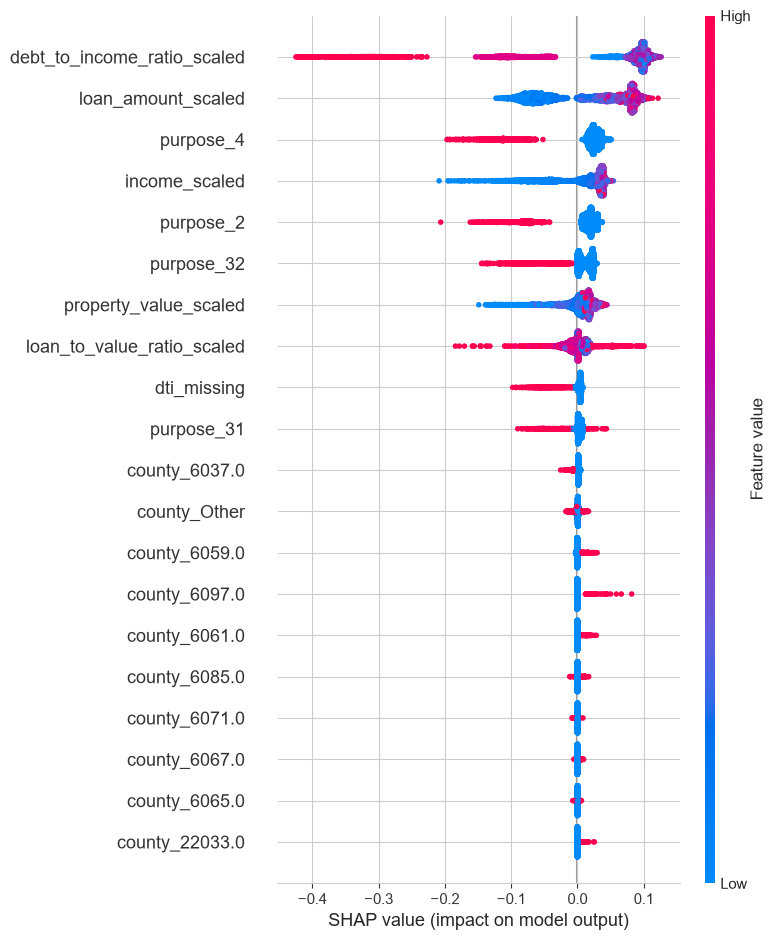

In [53]:
explainer_hmda = shap.TreeExplainer(rf_hmda)
shap_values_hmda = explainer_hmda.shap_values(X_hmda_test.sample(5000, random_state=42)) 

print(shap_values_hmda.shape)  

shap_values_hmda_class1 = shap_values_hmda[:, :, 1]
shap.summary_plot(shap_values_hmda_class1, X_hmda_test.sample(5000, random_state=42))

## Class 1 = "holds formal debt"

(4775, 41)


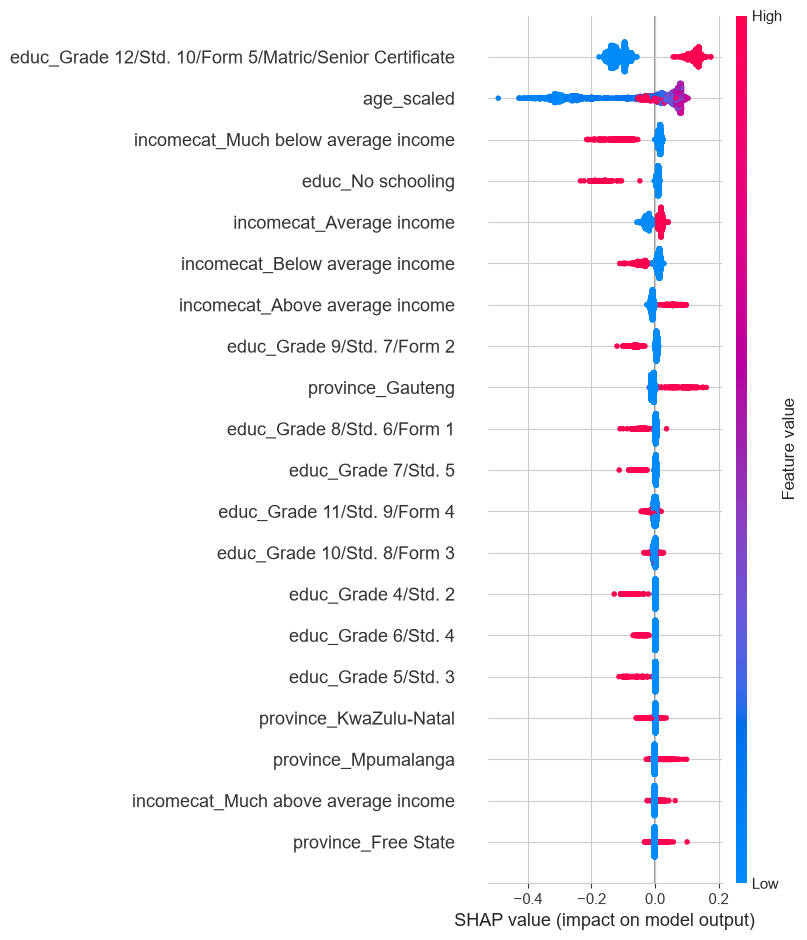

In [54]:

shap_values_class1 = shap_values_nids[:, :, 1]
print(shap_values_class1.shape) 

shap.summary_plot(shap_values_class1, X_nids_test)

## SHAP on German Credit — checking the age proxy

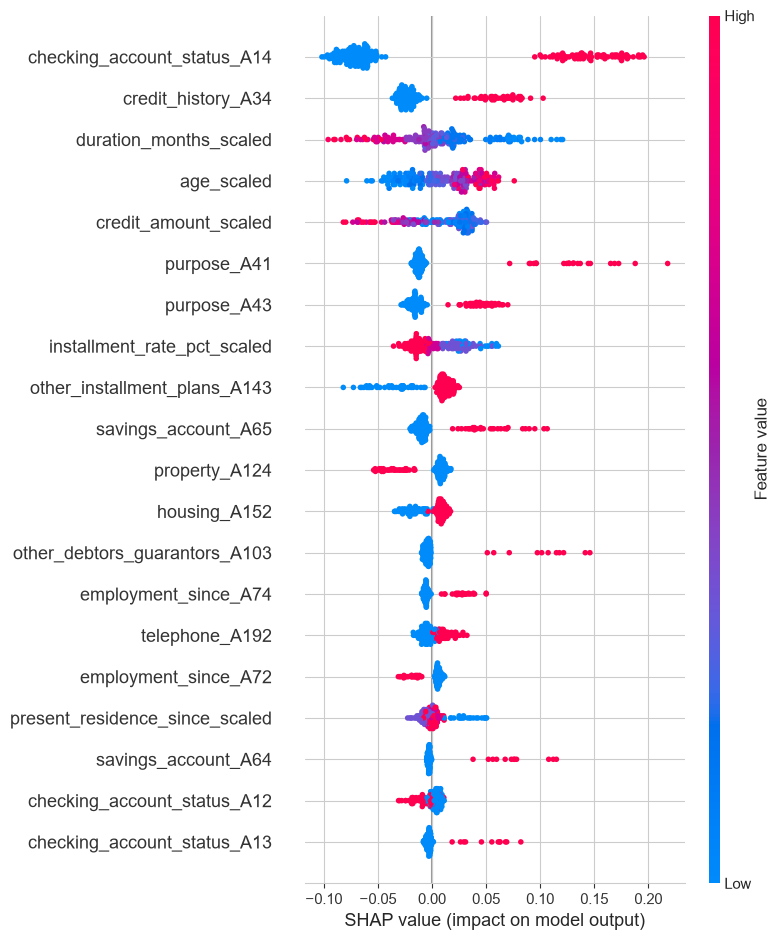

In [55]:
explainer_ger = shap.TreeExplainer(rf_ger)
shap_values_ger = explainer_ger.shap_values(X_ger_test)

shap_values_ger_class1 = shap_values_ger[:, :, 1]
shap.summary_plot(shap_values_ger_class1, X_ger_test)

## SHAP on HMDA — No-Proxy Model

(5000, 11, 2)


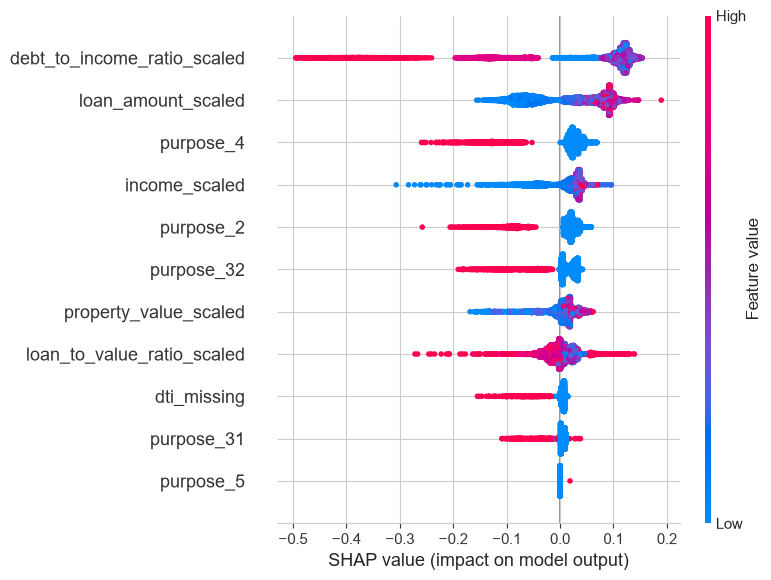

In [56]:

explainer_hmda_np = shap.TreeExplainer(rf_hmda_np)
sample_np = X_hmda_np_test.sample(5000, random_state=42)
shap_values_hmda_np = explainer_hmda_np.shap_values(sample_np)

print(shap_values_hmda_np.shape)  # expect (5000, n_features, 2)
shap_values_hmda_np_class1 = shap_values_hmda_np[:, :, 1]
shap.summary_plot(shap_values_hmda_np_class1, sample_np)


## SHAP on German Credit — No-Proxy Model 

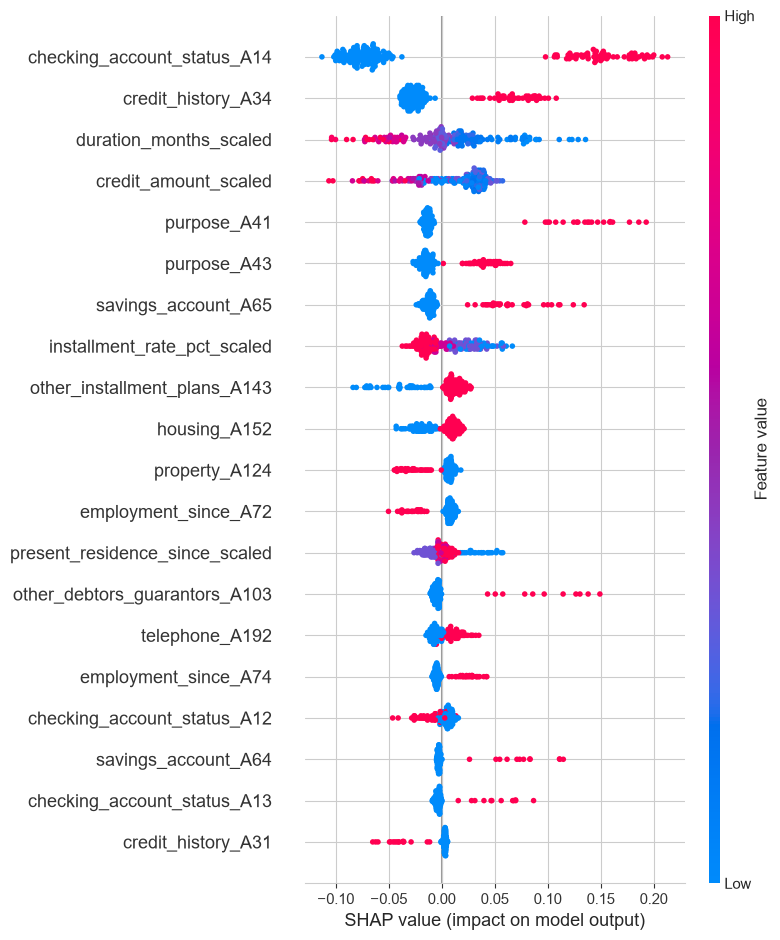

In [57]:

explainer_ger_np = shap.TreeExplainer(rf_ger_np)
shap_values_ger_np = explainer_ger_np.shap_values(X_ger_np_test)

shap_values_ger_np_class1 = shap_values_ger_np[:, :, 1]
shap.summary_plot(shap_values_ger_np_class1, X_ger_np_test)


## SHAP on NIDS — No-Proxy Model 

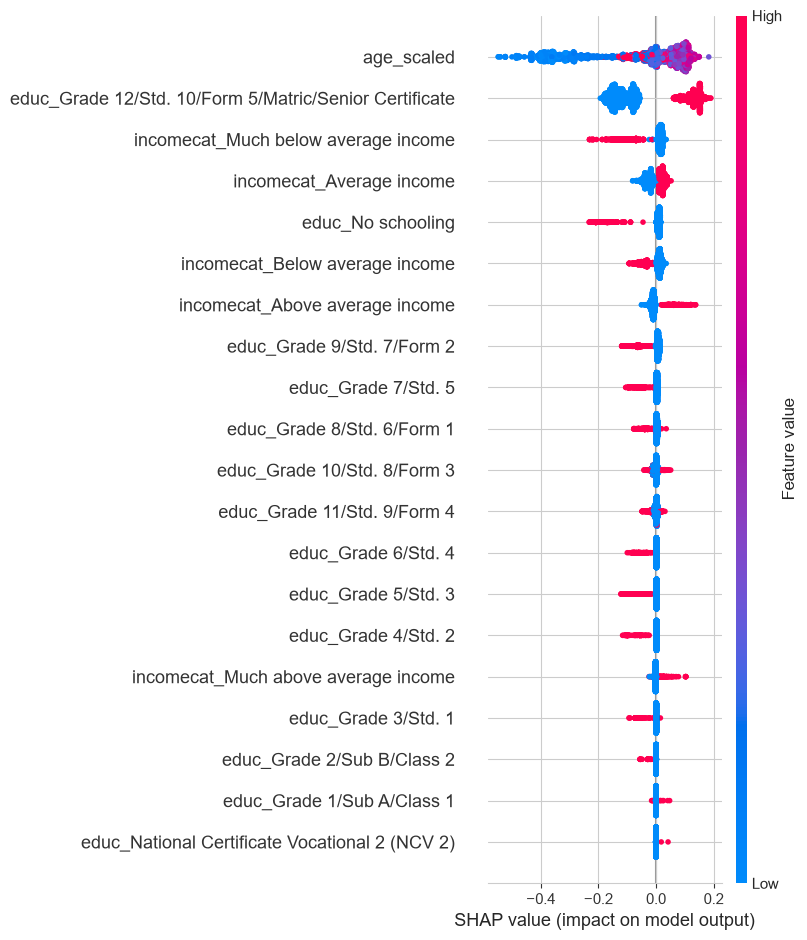

In [58]:

explainer_nids_np = shap.TreeExplainer(rf_nids_np)
shap_values_nids_np = explainer_nids_np.shap_values(X_nids_np_test)

shap_values_nids_np_class1 = shap_values_nids_np[:, :, 1]
shap.summary_plot(shap_values_nids_np_class1, X_nids_np_test)


## Proxy vs No-Proxy: Accuracy and Fairness Comparison Summary

This is the core comparison for Chapter 4 / RQ: does removing the proxy variable actually close the fairness gap, or does the model just re-encode the same bias through other correlated features (as the literature predicts, e.g. Datta et al., 2017)

In [59]:

comp = combined_results.copy()
comp["dataset"] = comp["model"].str.extract(r"^(HMDA|German|NIDS)")
comp["algorithm"] = comp["model"].str.extract(r"_(LogReg|RF)_")
comp["proxy_status"] = comp["model"].str.extract(r"_(withproxy|noproxy)$")

summary_cols = ["dataset", "algorithm", "sensitive_attr", "proxy_status",
                 "accuracy", "dp_diff", "di_ratio", "eo_diff"]
comparison_table = comp[summary_cols].sort_values(
    ["dataset", "algorithm", "sensitive_attr", "proxy_status"]
).reset_index(drop=True)

print("=== Proxy vs No-Proxy comparison (accuracy + fairness) ===")
print(comparison_table.to_string(index=False))

comparison_table.to_csv("proxy_vs_noproxy_comparison.csv", index=False)


=== Proxy vs No-Proxy comparison (accuracy + fairness) ===
dataset algorithm        sensitive_attr proxy_status  accuracy  dp_diff  di_ratio  eo_diff
 German    LogReg foreign_worker_status      noproxy  0.665000 0.233275  0.700075 0.322034
 German    LogReg foreign_worker_status    withproxy  0.670000 0.238511  0.693343 0.305085
 German    LogReg                   sex      noproxy  0.665000 0.030952  0.945148 0.125000
 German    LogReg                   sex    withproxy  0.670000 0.023810  0.957983 0.150000
 German        RF foreign_worker_status      noproxy  0.710000 0.333915  0.624346 0.318182
 German        RF foreign_worker_status    withproxy  0.695000 0.201862  0.740464 0.322034
 German        RF                   sex      noproxy  0.710000 0.004762  0.991667 0.200000
 German        RF                   sex    withproxy  0.695000 0.002381  0.995935 0.125000
   HMDA    LogReg      applicant_race-1      noproxy  0.688795 0.207675  0.691687 0.189731
   HMDA    LogReg      applican

In [60]:

pivot = comparison_table.pivot_table(
    index=["dataset", "algorithm", "sensitive_attr"],
    columns="proxy_status",
    values=["accuracy", "dp_diff", "eo_diff"]
)
pivot["accuracy_change"] = pivot[("accuracy", "noproxy")] - pivot[("accuracy", "withproxy")]
pivot["dp_diff_change"] = pivot[("dp_diff", "noproxy")] - pivot[("dp_diff", "withproxy")]
pivot["eo_diff_change"] = pivot[("eo_diff", "noproxy")] - pivot[("eo_diff", "withproxy")]

print("=== Change when proxy is removed (noproxy minus withproxy) ===")
print(pivot[["accuracy_change", "dp_diff_change", "eo_diff_change"]].to_string())


=== Change when proxy is removed (noproxy minus withproxy) ===
                                        accuracy_change dp_diff_change eo_diff_change
proxy_status                                                                         
dataset algorithm sensitive_attr                                                     
German  LogReg    foreign_worker_status       -0.005000      -0.005236       0.016949
                  sex                         -0.005000       0.007143      -0.025000
        RF        foreign_worker_status        0.015000       0.132054      -0.003852
                  sex                          0.015000       0.002381       0.075000
HMDA    LogReg    applicant_race-1             0.001427      -0.013699       0.013075
                  applicant_sex                0.001427      -0.082571      -0.007851
        RF        applicant_race-1             0.015917      -0.014508      -0.022130
                  applicant_sex                0.015917      -0.023539       

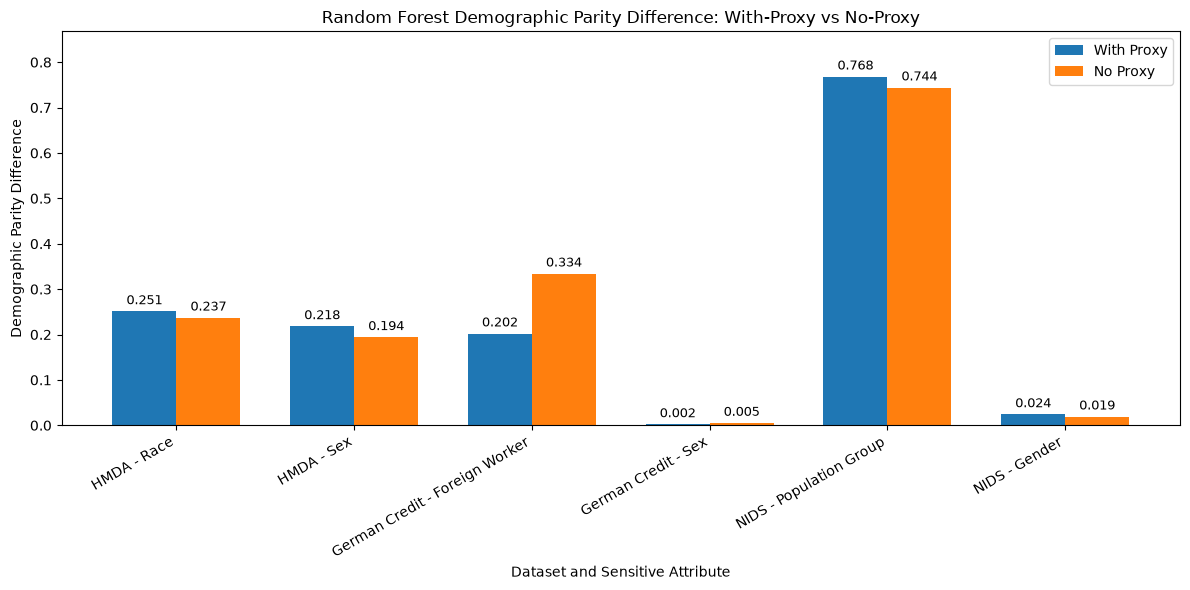

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Random Forest demographic parity results from Table 4.3
dp_data = pd.DataFrame({
    "Dataset / Sensitive Attribute": [
        "HMDA - Race",
        "HMDA - Sex",
        "German Credit - Foreign Worker",
        "German Credit - Sex",
        "NIDS - Population Group",
        "NIDS - Gender"
    ],
    "With Proxy": [
        0.251,
        0.218,
        0.202,
        0.002,
        0.768,
        0.024
    ],
    "No Proxy": [
        0.237,
        0.194,
        0.334,
        0.005,
        0.744,
        0.019
    ]
})

x = np.arange(len(dp_data))
width = 0.36

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(
    x - width/2,
    dp_data["With Proxy"],
    width,
    label="With Proxy"
)

bars2 = ax.bar(
    x + width/2,
    dp_data["No Proxy"],
    width,
    label="No Proxy"
)

ax.set_ylabel("Demographic Parity Difference")
ax.set_xlabel("Dataset and Sensitive Attribute")
ax.set_title(
    "Random Forest Demographic Parity Difference: "
    "With-Proxy vs No-Proxy"
)

ax.set_xticks(x)
ax.set_xticklabels(
    dp_data["Dataset / Sensitive Attribute"],
    rotation=30,
    ha="right"
)

ax.legend()

# Add values above bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f"{height:.3f}",
            xy=(bar.get_x() + bar.get_width()/2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9
        )

ax.set_ylim(
    0,
    max(
        dp_data["With Proxy"].max(),
        dp_data["No Proxy"].max()
    ) + 0.10
)

plt.tight_layout()
plt.show()